In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())





['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.525093724479512e-11 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


7.52790883669383e-11 deg2
7.52510476872822e-11 deg2


...

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/f

3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.491652259572426e-10 deg2


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:22:58.102' from MJD-AVG.
Set DATE-END to '2024-09-08T12:35:44.015' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-0

9.491458943030916e-10 deg2
9.491652069110604e-10 deg2
9.491651972183757e-10 deg2
7.524574264515582e-11 deg2


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [2]:

def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}
age_idx = logage_av0 == 6

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162m_mag[0].value - f210m_mag[0].value, f162m_mag[0].value, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))


 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

In [3]:
def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

paa_excess,  paa_excess_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess,  bra_excess_ew = get_line_excess(catalog, 'f405n', 'f410m')






Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
from astropy.table import Table
import numpy as np
from astropy import units as u


paa_excess_tab = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/pa_alpha_excess.fits')
paa_norm_excess = paa_excess_tab['normalized_excess']

fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F187N']
fwhm_f187n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f187n_au = (fwhm_f187n * 5400 *u.au).to(u.au)
print('fwhm_f187n:', fwhm_f187n, 'arcsec')
print('fwhm_f187n_au:', fwhm_f187n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
y = f162m_mag[0].value
x = f162m_mag[0].value - f210m_mag[0].value
mask_paa = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(paa_excess) & (paa_excess>0)


dereddend_paa_excess = paa_norm_excess * 10**(0.4*av_estimate[mask_paa]*ext(1/1.87/u.um))

tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
wave_paa = tab_paa['Wavelength'] 
trans_paa = tab_paa['Transmission']
# get the frequency width of PaA from svo_fps
delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
print('delta_lam:', delta_lam)
delta_nu_paa= (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
#F_paa = (excess*u.Jy * delta_nu).to(u.erg/u.s/u.cm**2)
#L_paa = (F_paa * 4 * np.pi * (5400*u.pc)**2).to(u.Lsun) 
#EM_from_paa = (L_paa / (const.h * const.c / (1.87e-6*u.m) * 3e-14*u.cm**3/u.s)).to(u.pc*u.cm**(-6))  #
#caseA_recomb_coeff = 4.18e-14 * u.cm**3/u.s  # Case A recombination coefficient for PaA at 10,000 K
#caseB_recomb_coeff = 3.14e-14 * u.cm**3/u.s  # Case B recombination coefficient for PaA at 10,000 K
I_paa = (dereddend_paa_excess * u.Jy * delta_nu_paa/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_paa = (I_paa / delta_nu_paa).to(u.MJy/u.sr)
#I_paa = (dereddend_excess * u.Jy * delta_nu/ (fwhm_f187n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
#EM_from_IPaa = (4*np.pi*u.sr*I_paa / (const.h*const.c/(1.87e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
EM_from_IPaa = 1/6.4 * 1e6*S_paa.value * u.pc/u.cm**6 
density_from_paa = ((EM_from_IPaa / fwhm_f187n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_paa:', density_from_paa)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * fwhm_f187n_au**3).to(u.s**-1).value) 



paa_excess_tab['dereddend_paa_excess'] = dereddend_paa_excess
paa_excess_tab['I_paa'] = I_paa
paa_excess_tab['S_paa'] = S_paa
paa_excess_tab['EM_from_IPaa'] = EM_from_IPaa
paa_excess_tab['density_from_paa'] = density_from_paa
paa_excess_tab['Q_from_density'] = Q_from_density

paa_excess_tab.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/pa_alpha_excess_with_Q.fits', overwrite=True)


bra_excess_tab = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/br_alpha_excess.fits')
bra_norm_excess = bra_excess_tab['normalized_excess']


fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == 'F405N']
fwhm_f405n = float(row['PSF FWHM (arcsec)'][0])
fwhm_f405n_au = (fwhm_f405n * 5400 *u.au).to(u.au)
print('fwhm_f405n:', fwhm_f405n, 'arcsec')
print('fwhm_f405n_au:', fwhm_f405n_au)
# convert Jy to EM
# get the frquency width of PaA from svo_fps
mask_bra = (av_estimate > 12) & np.isfinite(x) & np.isfinite(y) & np.isfinite(bra_excess) & (bra_excess>0)
delta_nu_bra= (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)

dereddend_bra_excess = bra_norm_excess * 10**(0.4*av_estimate[mask_bra]*ext(1/4.05/u.um))
I_bra = (dereddend_bra_excess * u.Jy * delta_nu_bra/ (fwhm_f405n*u.arcsec)**2).to(u.erg/u.s/u.cm**2/u.sr)
S_bra = (I_bra / delta_nu_bra).to(u.MJy/u.sr)
EM_from_IBra = 1/6.4 * 1e6*S_bra.value * u.pc/u.cm**6 
density_from_bra = ((EM_from_IBra / fwhm_f405n_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
print('density_from_bra:', density_from_bra)
Q_from_density = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * fwhm_f405n_au**3).to(u.s**-1).value) 

bra_excess_tab['dereddend_bra_excess'] = dereddend_bra_excess
bra_excess_tab['I_bra'] = I_bra
bra_excess_tab['S_bra'] = S_bra
bra_excess_tab['EM_from_IBra'] = EM_from_IBra
bra_excess_tab['density_from_bra'] = density_from_bra
bra_excess_tab['Q_from_density'] = Q_from_density

bra_excess_tab.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/br_alpha_excess_with_Q.fits', overwrite=True)

fwhm_f187n: 0.064 arcsec
fwhm_f187n_au: 345.6 AU
delta_lam: 236.59542237910327 Angstrom
density_from_paa: [nan nan nan ... nan nan nan] 1 / cm3
fwhm_f405n: 0.136 arcsec
fwhm_f405n_au: 734.4000000000001 AU
density_from_bra: [           nan            nan            nan ...            nan
 14977.01137375 63701.92281594] 1 / cm3


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


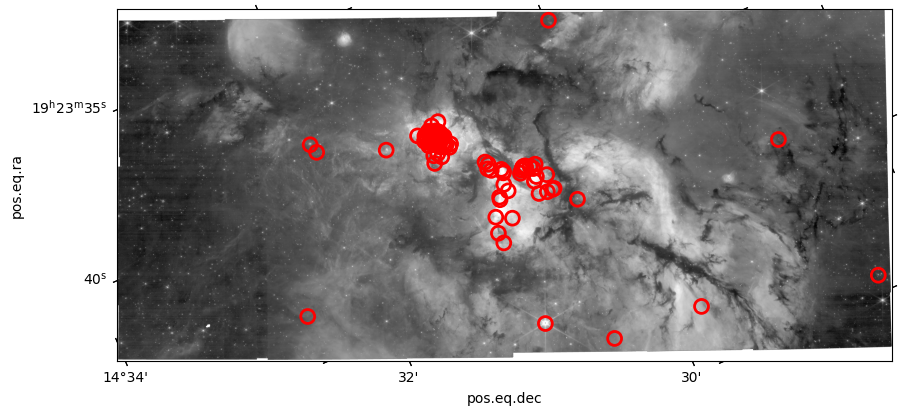

In [10]:
from astropy.visualization import simple_norm
mask_high_paa = paa_excess_tab['Q_from_density'] > 47.5
skycoord = catalog['skycoord_ref']
skycoord_high_paa = skycoord[mask_paa][mask_high_paa]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=WCS(f187n_header))
norm =simple_norm(fits.getdata(image_filenames['f187n'], ext=('SCI', 1)), stretch='log', percent=99.5)
ax.imshow(fits.getdata(image_filenames['f187n'], ext=('SCI', 1)), origin='lower', cmap='gray',norm=norm)
ax.scatter(skycoord_high_paa.ra.deg, skycoord_high_paa.dec.deg, transform=ax.get_transform('world'), s=100, edgecolor='red', facecolor='none', lw=2, label='High PAA Sources')